
=== Euclidean ===
Accuracy : 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


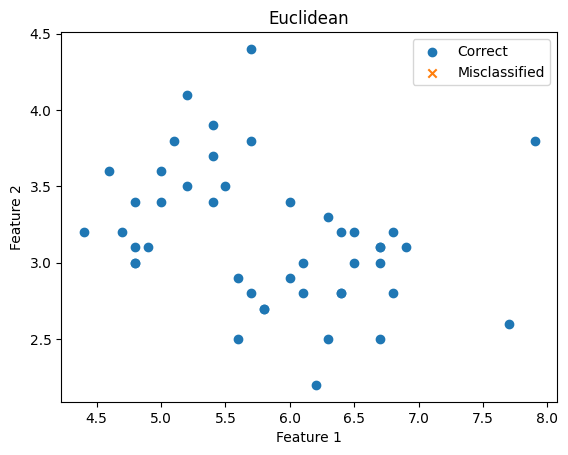


=== Minkowski (p=3) ===
Accuracy : 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


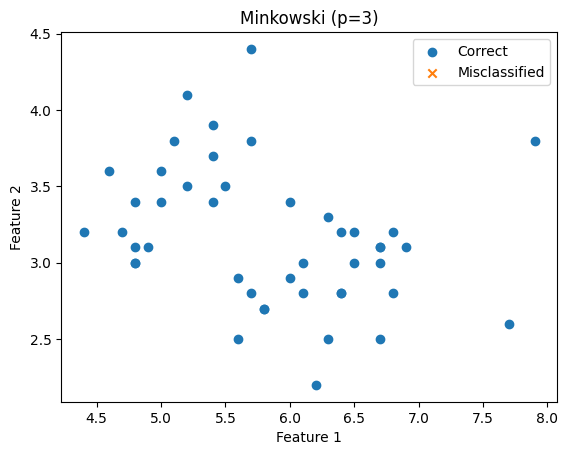


=== Mahalanobis ===
Accuracy : 0.9111111111111111
Confusion Matrix:
 [[19  0  0]
 [ 0 10  3]
 [ 0  1 12]]


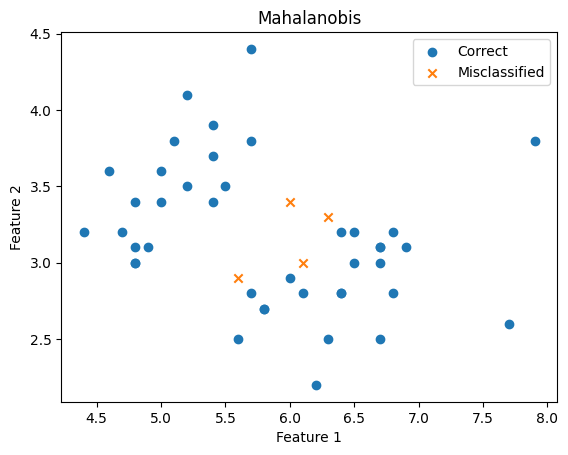

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.metrics import confusion_matrix


iris = load_iris()
X = iris.data[:, :4]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


def euclidean(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

def minkowski(x1, x2, p=3):
    return np.power(np.sum(np.abs(x1 - x2) ** p), 1/p)

def mahalanobis(x1, x2, inv_cov):
    diff = x1 - x2
    return np.sqrt(np.dot(np.dot(diff.T, inv_cov), diff))


def knn_predict(X_train, y_train, X_test, k, distance_type, p=3):
    predictions = []

    if distance_type == "mahalanobis":
        cov = np.cov(X_train.T)
        inv_cov = np.linalg.inv(cov)

    for x in X_test:
        distances = []

        for i, x_train in enumerate(X_train):

            if distance_type == "euclidean":
                d = euclidean(x, x_train)

            elif distance_type == "minkowski":
                d = minkowski(x, x_train, p)

            elif distance_type == "mahalanobis":
                d = mahalanobis(x, x_train, inv_cov)

            distances.append((d, y_train[i]))

        distances.sort(key=lambda x: x[0])
        k_neighbors = distances[:k]
        labels = [label for _, label in k_neighbors]

        most_common = Counter(labels).most_common(1)[0][0]
        predictions.append(most_common)

    return np.array(predictions)


def evaluate_and_plot(y_test, y_pred, X_test, title):
    acc = np.sum(y_test == y_pred) / len(y_test)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== {title} ===")
    print("Accuracy :", acc)
    print("Confusion Matrix:\n", cm)


    plt.figure()


    correct = y_test == y_pred
    plt.scatter(X_test[correct, 0], X_test[correct, 1], label="Correct")


    wrong = y_test != y_pred
    plt.scatter(X_test[wrong, 0], X_test[wrong, 1], marker='x', label="Misclassified")

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()


# Euclidean
y_pred_euc = knn_predict(X_train, y_train, X_test, 3, "euclidean")
evaluate_and_plot(y_test, y_pred_euc, X_test, "Euclidean")

# Minkowski
y_pred_min = knn_predict(X_train, y_train, X_test, 3, "minkowski", p=3)
evaluate_and_plot(y_test, y_pred_min, X_test, "Minkowski (p=3)")

# Mahalanobis
y_pred_mah = knn_predict(X_train, y_train, X_test, 3, "mahalanobis")
evaluate_and_plot(y_test, y_pred_mah, X_test, "Mahalanobis")

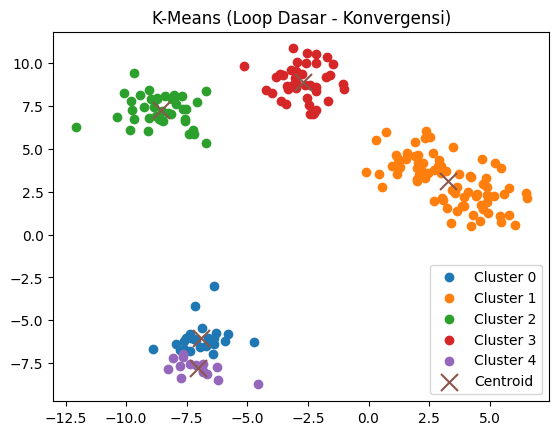

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


X, _ = make_blobs(n_samples=200, centers=5, random_state=42)

k = 5
np.random.seed(42)

# inisialisasi awal centroid atau pusat klaster
centroids = X[np.random.choice(len(X), k, replace=False)]


def dist(a, b):
    return np.sqrt(np.sum((a - b)**2))


converged = False

while not converged:

    labels = []

    # assign cluster
    for x in X:
        distances = []
        for c in centroids:
            distances.append(dist(x, c))

        labels.append(np.argmin(distances))

    labels = np.array(labels)

    # simpan centroid lama
    old_centroids = centroids.copy()

    # update centroid
    new_centroids = []
    for i in range(k):
        points = X[labels == i]
        if len(points) > 0:
            new_centroids.append(np.mean(points, axis=0))
        else:
            new_centroids.append(centroids[i])

    centroids = np.array(new_centroids)

    # cek konvergensi
    if np.allclose(old_centroids, centroids):
        converged = True

plt.figure()

for i in range(k):
    pts = X[labels == i]
    plt.scatter(pts[:, 0], pts[:, 1], label=f"Cluster {i}")

plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=150, label="Centroid")

plt.title("K-Means (Loop Dasar - Konvergensi)")
plt.legend()
plt.show()

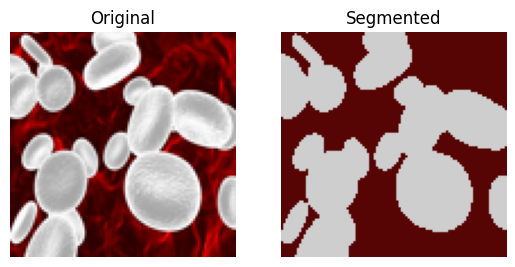

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


#img = Image.open("gambar.png")
img= Image.open('sel darah.jpg')
img = img.resize((100, 100))

img = img.convert('RGB')

img_np = np.array(img)

img_np = img_np[:, :, :3]

# ubah ke bentuk (jumlah_pixel, 3)
pixels = img_np.reshape(-1, 3)


k = 2
np.random.seed(42)


centroids = pixels[np.random.choice(len(pixels), k, replace=False)]


def dist(a, b):
    return np.sqrt(np.sum((a - b)**2))


converged = False

while not converged:

    labels = []

    # assign cluster
    for p in pixels:
        distances = []
        for c in centroids:
            distances.append(dist(p, c))
        labels.append(np.argmin(distances))

    labels = np.array(labels)

    old_centroids = centroids.copy()

    # update centroid
    new_centroids = []
    for i in range(k):
        cluster_pixels = pixels[labels == i]
        if len(cluster_pixels) > 0:
            new_centroids.append(np.mean(cluster_pixels, axis=0))
        else:
            new_centroids.append(centroids[i])

    centroids = np.array(new_centroids)

    # cek konvergensi
    if np.allclose(old_centroids, centroids):
        converged = True

segmented_pixels = centroids[labels].astype(np.uint8)
segmented_img = segmented_pixels.reshape(img_np.shape)


plt.figure()

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Segmented")
plt.imshow(segmented_img)
plt.axis("off")

plt.show()